In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from statistics import mean

# A brief intro to gradient descent and neural networks

Feel free to skip.

In [2]:
def log_loss(true, pred):
    return ((true * np.log(pred)) + ((1 - true) * np.log(1 - pred))).sum() / -true.shape[0]

def sigmoid(pred):
    return 1 / (1 + np.exp(-pred))

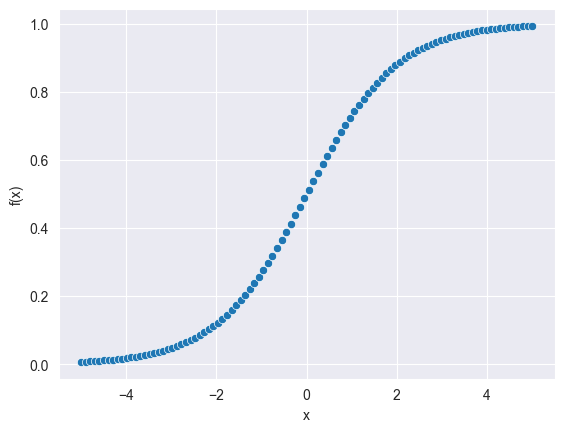

In [3]:
linspace = np.linspace(-5, 5, 100)
ax = sns.scatterplot(y=sigmoid(linspace), x=linspace) 
ax.set_ylabel("f(x)")
ax.set_xlabel("x");

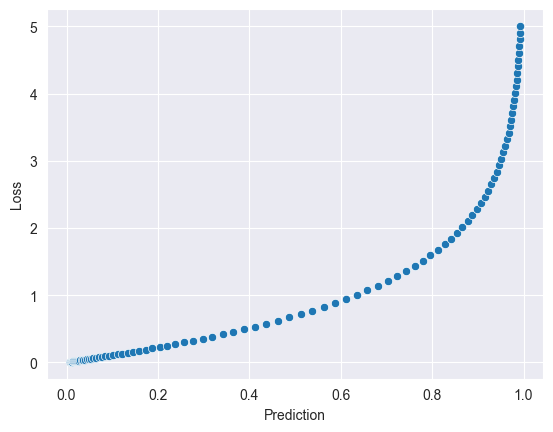

In [4]:
linspace = sigmoid(np.linspace(-5, 5, 100))
true_class = 0.0
losses = np.apply_along_axis(lambda x: log_loss(np.array([true_class]), x), 0, linspace.reshape(1, -1))
ax = sns.scatterplot(y=losses, x=linspace)
ax.set_xlabel("Prediction")
ax.set_ylabel("Loss");

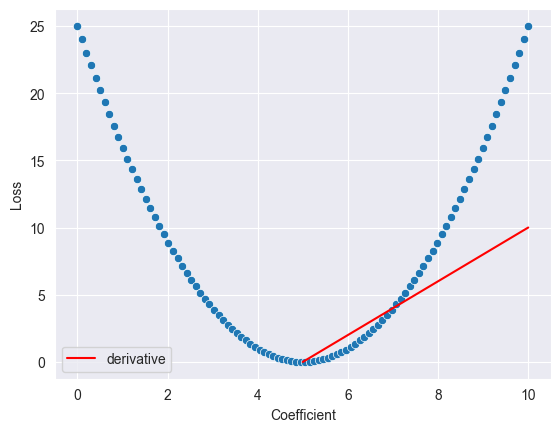

In [5]:
coef = np.linspace(0, 10, 100)
loss = (coef - 5) ** 2

line = lambda x: 2 * (x - 5)
ax = sns.scatterplot(x=coef, y=loss)
plt.plot([5, 10], line(np.array([5, 10])), color="red", label="derivative")
plt.legend()
ax.set_xlabel("Coefficient")
ax.set_ylabel("Loss");

In [6]:
X = np.random.normal(size=200).reshape(-1, 2)
X[:5]

array([[-0.49456894,  0.33290977],
       [ 1.50600448,  1.36419374],
       [ 0.38897989, -0.11923666],
       [ 2.10532622, -0.17044577],
       [-0.44714941,  2.17032051]])

In [7]:
y = np.round(sigmoid((2 * X[:, 0] + 3 * X[:, 1])))
y[:5]

array([1., 1., 1., 1., 1.])

In [8]:
learning_rate = 0.1
nepoch = 10

w = np.random.normal(scale=0.1, size=2).reshape(1, 2)
print("initial weights", w[0], "\n")
for i in range(nepoch):
    preds = sigmoid(w.dot(X.T))[0]
    gradient = np.sum((y - preds).reshape(-1, 1) * X, axis=0).reshape(1, 2) / X.shape[0]
    w += learning_rate * gradient
    #print(gradient)

    preds = sigmoid(w.dot(X.T))[0]
    loss = log_loss(y, preds)

    print("loss:", loss)
    print("weights:", w[0])

initial weights [-0.0452101   0.13951103] 

loss: 0.6514142122665778
weights: [-0.02171578  0.16608354]
loss: 0.6395133982487402
weights: [0.00125976 0.19207202]
loss: 0.628127611879309
weights: [0.02372889 0.21749372]
loss: 0.6172313206572083
weights: [0.04570424 0.24236599]
loss: 0.6067998739208254
weights: [0.06719866 0.26670621]
loss: 0.5968095636413357
weights: [0.08822507 0.29053166]
loss: 0.5872376653117215
weights: [0.10879644 0.3138594 ]
loss: 0.5780624615829892
weights: [0.12892569 0.33670625]
loss: 0.5692632512264413
weights: [0.14862562 0.35908868]
loss: 0.5608203458533779
weights: [0.16790892 0.38102279]


# Learning to rank

- A supervised learning task
- Attempts to optimally order a list (or lists) of items.
- Usually used for information retrieval: search engines, recommenders.

There are currently 3 general kinds of methods for this task.

- Point-wise
    - Basically just regression or classification
    - Considers each list item independently of others
    - Rankprop (MSE regression with adjustments)
        - https://proceedings.neurips.cc/paper/1995/hash/36a16a2505369e0c922b6ea7a23a56d2-Abstract.html
    - P-rank (ordinal regression)
        - https://papers.nips.cc/paper/2001/file/5531a5834816222280f20d1ef9e95f69-Paper.pdf
    - mcrank (multiple classification/ordinal classification)
        - http://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.992.5789&rep=rep1&type=pdf

- Pair-wise
    - Consider pairs of items and decide which should be higher
    - RankingSVM/RankSVM/SVMrank
        - https://www.hindawi.com/journals/cin/2017/4629534/
        - https://www.cs.cornell.edu/people/tj/svm_light/svm_rank.html
        - https://doi.org/10.1007/978-3-642-01307-2_39
    - RankBoost
        - https://www.jmlr.org/papers/volume4/freund03a/freund03a.pdf
    - Ranknet
        - https://www.microsoft.com/en-us/research/wp-content/uploads/2005/08/icml_ranking.pdf
    - LambdaRank/LambdaMART
        - https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/lambdarank.pdf

- List-wise
    - Optimise the ordering of whole lists of items at a time
    - Requires numerous lists of items
    - Often used for information retrieval (match relevance) or product display order (likelihood of sale)
    - e.g. LambdaRank/LambdaMART
    - softRank
    - listRank
    - listMLE
    
    
    
Recommended resource from Guido Zuccon
- Hang Li, "Learning to Rank for Information Retrieval and Natural Language Processing" https://www.morganclaypool.com/doi/abs/10.2200/S00607ED2V01Y201410HLT026

   

LTR is closely related to (and is incorporated in) some recommender system problems, but the literature doesn't seem to intersect much.
Lots more information available on recommenders so I'd add it as a search term if you're trying to learn this stuff.

Collaborative filtering might form part of your initial selection of documents to present.
Ranking and reranking in recommenders often don't use the term "learning to rank" so look around.

- https://arxiv.org/ftp/arxiv/papers/1205/1205.2618.pdf
- https://arxiv.org/pdf/1812.04109.pdf
- https://arxiv.org/pdf/1904.06813.pdf
- https://arxiv.org/abs/1804.05936

## Data and labels

Selection of features usually some indicator of relevance to a query term.

- Distance/Similarity of word/sentence embeddings
- PageRank
- Clicks
- User history

Could also just be general features used for regression or classification and a query term as categorical factor.

> A lot of feature engineering has  historically been done in search engines (so you can imagine how happy people are to be moving to DL).
> Complex indexing time features are often computed.
> Complex query time features are more challenging, as they add to the query latency.
> So often a cascade of rankers is employed (e.g. Twitter uses 3 or 4 depths of cascades) with the complex query-time features being computed only at later stages.
>
> \- Guido Zuccon

Labels used are relevance or priority scores for each item in your training/test datasets (e.g. 0, 1, 2, 3, 4).

Can also be pairwise decisions on whether one should be higher than the other (like a binary classifier for each pair).

## Why do I care about this stuff?


#### Protein functional annotation

Came about LTR when I was looking at new gene ontology term prediction methods and came across [GOLabeler](https://academic.oup.com/bioinformatics/article/34/14/2465/4924212).
GoLabeler takes a protein sequence, performs several analyses and uses LTR to order the resulting GO terms by relevance (i.e. a multi-label problem).

#### Disease resistance scoring

Quantifying (phenotypically) complex traits and combinations of traits can be difficult.
Scoring methods have been used for years, and researchers are hesitant/unable to move into more automated areas.

Below is a typical scoring key used for a wheat necrotrophic pathogen (Ptr/Yellow spot)...

![](https://media.springernature.com/full/springer-static/image/art%3A10.1007%2Fs10681-016-1660-z/MediaObjects/10681_2016_1660_Fig1_HTML.jpg)

> Dinglasan, E., Godwin, I.D., Mortlock, M.Y. et al. Resistance to yellow spot in wheat grown under accelerated growth > conditions. Euphytica 209, 693–707 (2016). https://doi.org/10.1007/s10681-016-1660-z


It's difficult to assign a distinct quantitative score of disease severity (or even an ordinal one), but it's much easier to say that one leaf is more severely diseased than another.

#### Protein candidate ranking.

There is a class of proteins called "effectors" that we're interested in.
Effectors share little sequence similarity but have some common characteristics related to size, charge, motifs etc.
But not all indicators of these characteristics are perfect (e.g signal peptide prediction), and not all effectors have these characteristics (large size).

The idea is to use LTR to learn a static sorting function, so that things with more of the indicator characteristics are nearer the top of the list in a big spreadsheet but we're not "throwing out" good candidates (jut a bit further down the list).

Wrote a pipeline called [predector](https://github.com/ccdmb/predector) based on this idea, and it's super useful.


#### A few other interesting cases

- Drug selection for individual patients based on genomic information
    - https://ieeexplore.ieee.org/abstract/document/8395000?casa_token=U1XwW3DNc34AAAAA:gLBTlk1uCfJQZpxTi_emFrCGHB23WiFNL2engdCvI8yrQMTFao3rslhgvs3kLFfZ48k113I9WF7u
- Ranking individual treatment effects (Uplift modelling)
    - https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=9311871&tag=1
- Diseases name normalisation/standardisation
    - https://academic.oup.com/bioinformatics/article/29/22/2909/312804?login=true


---


Adjusting the objective of the modelling rather than changing requirements of researchers/input:

- lower barrier to uptake by researchers (easier data generation, results closer to what they expect)
- viable intermediate tools until traits can be broken down into separate components
- potential for interactive reinforcement/labelling

## Metrics

Specialised evaluation metrics are all list-wise.
Point- and pair-wise algorithms use a different loss function during training.

Binary relevance (0 or 1):
- Mean average precision (MAP) - Like an AUC for ranking.
- Mean reciprocal rank (MRR) - Position of first relevant item
- accuracy@k (or precision, recall etc)

Multi-level relevance (0, 1, 2, ...):
- Normalised DCG (NDCG)
- Expected reciprocal rank (ERR) https://dl.acm.org/doi/pdf/10.1145/1645953.1646033

In [9]:
def mrr(true, pred):
    """ Mean reciprocal rank
    
    all you care about is the top hit.
    
    true: array of 0 or 1 indicating relevance
    pred: scoring function producing sorted list in descending order.
    """
    
    import numpy as np
    from statistics import mean
    
    reciprocal_ranks = []
    
    for i in range(true.shape[0]):
        order = np.argsort(pred[i])[::-1]
        ranked = true[i][order]

        # Find the position of the first element ranked as relevant
        list_rank = np.argmax(ranked > 0) + 1  # Correct for zero indexing.

        reciprocal_ranks.append(1 / list_rank)

    return mean(reciprocal_ranks)  # Mean of list scores

p = np.array([
    [3, 2, 1],
    [3, 2, 1],
    [3, 2, 1]
])

t = np.array([
    [0, 0, 1],
    [0, 1, 1],
    [1, 1, 0]
])

mrr(t, p)

np.float64(0.6111111111111112)

In [10]:
def average_precision(true, pred):
    import numpy as np
    
    average_precisions = []
    
    for i in range(true.shape[0]):
        order = np.argsort(pred[i])[::-1]
        ranked = true[i][order]
        
        running_nrelevant = np.cumsum(ranked)
        running_rank = np.arange(1, ranked.shape[0] + 1)
        running_precision = running_nrelevant[ranked > 0] / running_rank[ranked > 0]

        average_precisions.append(running_precision.mean())

    return np.array(average_precisions)

p = np.array([
    [3, 2, 1],
    [3, 2, 1],
    [3, 2, 1]
])

t = np.array([
    [0, 0, 1],
    [0, 1, 1],
    [1, 1, 0]
])

average_precision(t, p)

array([0.33333333, 0.58333333, 1.        ])

In [11]:
def map_(true, pred):
    return average_precision(true, pred).mean()

map_(t, p)

np.float64(0.6388888888888888)

### NDCG

Applies a "discount" to scores based on sorted list index.
There are multiple versions, and different implementations may yield different results.

$ DCG@N = \sum_{i=1}^{N} \frac{y_i}{log(1+i)} $

The one people actually use:

$ DCG@N = \sum_{i=1}^{N} \frac{2^{y_i} - 1}{log(1+i)} $

>  The version with $2^{y{_i}}$ is often preferred as has a smoother gain curve for the different grades of relevance - Guido Zuccon


To find the normalised DCG (NDCG) you divide the DCG by the ideal DCG.
Ideal DCG is obtained by a perfect predicted ordering wrt your relevance labels.

Great overview and analysis of NDCG in:

Clémençon S., Lugosi G., Vayatis N. (2005) Ranking and Scoring Using Empirical Risk Minimization. In: Auer P., Meir R. (eds) Learning Theory. COLT 2005. Lecture Notes in Computer Science, vol 3559. Springer, Berlin, Heidelberg. https://doi.org/10.1007/11503415_1

In [12]:
def discounted_cumulative_gain(true, pred, at=None, original=False):
    import numpy as np

    dcgs = []

    for i in range(true.shape[0]):
        order = np.argsort(pred[i])[::-1]
        ranked = true[i][order]

        if at is not None:
            # Only evaluating in top k
            ranked = ranked[:at]

        if original:
            # Ranked score divided by rank of prediction
            # Note log2 means values with higher ranks (i.e. less relevant)
            # has weaker effect on score.
            ratios = ranked / np.log2(np.arange(1, ranked.shape[0] + 1) + 1)
        else:
            # Alternative ratio to make emphasis on most relevant stronger.
            ratios = ((2 ** ranked) - 1) / np.log2(np.arange(1, ranked.shape[0] + 1) + 1)
        dcgs.append(ratios.sum())

    return np.array(dcgs)

p = np.array([
    [3, 2, 1],
    [3, 2, 1],
    [3, 2, 1]
])

t = np.array([
    [0, 0, 1],
    [0, 1, 1],
    [1, 1, 0]
])

discounted_cumulative_gain(t, p)

array([0.5       , 1.13092975, 1.63092975])

In [13]:
discounted_cumulative_gain(t, t)

array([1.        , 1.63092975, 1.63092975])

In [14]:
discounted_cumulative_gain(t, p) / discounted_cumulative_gain(t, t)

array([0.5      , 0.6934264, 1.       ])

In [15]:
def normalised_dcg(true, pred, at=None, original=False):
    # Actual dcg
    dcgs = discounted_cumulative_gain(true, pred, at, original=original)

    # Maximum possible dcg
    ideal_dcgs = discounted_cumulative_gain(true, true, at, original=original)

    # Handle edge case where ideal dcg is zero
    # This could happen if you have no relevant items in your list.
    dcgs[ideal_dcgs == 0.] = 0
    ideal_dcgs[ideal_dcgs == 0.] = 1

    return (dcgs / ideal_dcgs).mean()

normalised_dcg(t, p)

np.float64(0.7311421345390903)

In [16]:
p = np.array([
    np.arange(5)[::-1],
    np.arange(5)[::-1]
])

t = np.array([
    [1, 0, 1, 1, 0],
    [0, 0, 0, 1, 1]
])

print("MRR", mrr(t, p))

print("MAP", [map_(ti.reshape(1, -1), pi.reshape(1, -1)) for ti, pi in zip(t, p)])
print("MAP", map_(t, p))

print("NDCG", discounted_cumulative_gain(t, p) / discounted_cumulative_gain(t, t))
print("NDCG", normalised_dcg(t, p))

MRR 0.625
MAP [np.float64(0.8055555555555555), np.float64(0.325)]
MAP 0.5652777777777778
NDCG [0.90602544 0.50126584]
NDCG 0.7036456354382847


In [17]:
# A multi-level example

true = np.array([
    [3, 2, 3, 0, 1, 2],
    [0, 1, 2, 2, 3, 3],
    [0, 3, 0, 3, 0, 3],
    [3, 0, 3, 0, 3, 0],
])

pred = np.array([
    [5, 4, 3, 2, 1, 0],
    [5, 4, 3, 2, 1, 0],
    [5, 4, 3, 2, 1, 0],
    [5, 4, 3, 2, 1, 0],
])

discounted_cumulative_gain(true, pred) / discounted_cumulative_gain(true, true)

array([0.94881075, 0.59089746, 0.66534971, 0.88545988])

Sci-kit learn has an implementation of ndcg but it only uses the original score function (rather than the in-practise standard $2^i - 1$).

In [18]:
normalised_dcg(true, pred, original=True)

np.float64(0.7931987348917845)

In [19]:
from sklearn.metrics import ndcg_score
ndcg_score(true, pred)

0.7931987348917845

Note that using priorities `1, 2, ...` instead of `0, 1, ...` will give different results.

"Correct" usage is to start at 0 for irrelevant.

In [20]:
normalised_dcg(true, pred)

np.float64(0.7726294517134219)

In [21]:
normalised_dcg(true + 1, pred)

np.float64(0.7955308580375091)

NDCG can be a bit difficult to interpret, and varies with length of list and labels used.
The worst possible order will still have NDCG > 0.

In [22]:
discounted_cumulative_gain(true, (true.max() - true)) / discounted_cumulative_gain(true, true)

array([0.59089746, 0.59089746, 0.55080959, 0.55080959])

And the average NDCG given by randomly ordered lists can be quite high.

In [23]:
from numpy.random import default_rng

In [24]:
rng = default_rng()

In [25]:
pred2 = np.array([
    rng.choice(np.arange(6), 6, replace=False),
    rng.choice(np.arange(6), 6, replace=False),
    rng.choice(np.arange(6), 6, replace=False),
    rng.choice(np.arange(6), 6, replace=False)
])
pred2

array([[3, 5, 1, 0, 4, 2],
       [1, 5, 2, 4, 0, 3],
       [1, 4, 5, 2, 3, 0],
       [0, 4, 2, 5, 3, 1]])

In [26]:
discounted_cumulative_gain(true, pred2) / discounted_cumulative_gain(true, true)

array([0.76263317, 0.69736189, 0.66534971, 0.60390716])

Rather than thinking about "how much better than random we are are doing", it might be better to think of "how far away from the optimal solution are we?".


#### Expected reciprocal rank (ERR)

People don't seem to use this so much.

$$
ERR = \sum_{r=1}^{N} \frac{1}{r}R_r\prod_{i=1}^{r-1}(1-R_i)
$$

if $y_m$ is the maximum label value,

$$
R_i = \frac{2^{y_i}-1}{2^{y_m}}
$$

## Pointwise ranking - MCrank

Learning to rank as "multiple ordinal classification" with boosted trees.

http://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.992.5789&rep=rep1&type=pdf

- Show that there's a relationship between DCG and multiple classification.
- Two multiple classification approaches (and a regression based solution) were quite successful compared to LambdaRank.

Expected rank:

1. Train a multi-class predictor (one class for each rank level: 0, 1, 2, ...).
2. Multiply the classification probabilities with some monotonically increasing function of the rank levels.

$$
S_i = \sum_{i=0}^{K - 1}\bar{P}(i = k)f(k)
$$

3. Sort by $S_i$


I'll define some example data that i'll use for all of the examples.

In [27]:
np.random.seed(666)

X = np.random.normal(size=20000).reshape(-1, 2)
X[:5]

array([[ 0.82418808,  0.479966  ],
       [ 1.17346801,  0.90904807],
       [-0.57172145, -0.10949727],
       [ 0.01902826, -0.94376106],
       [ 0.64057315, -0.78644317]])

In [28]:
def quantise(arr, maxpriority=3):
    return (maxpriority * (arr - arr.min()) / (arr.max() - arr.min())).round()

# This just makes sure all have all relevance levels
y = np.zeros(10000)
i = 0
for j in range(100, 10001, 100):
    y[i:j] = quantise((5 * X[i:j, 0] + 1.5 * X[i:j, 1]))
    i = j

np.unique(y)

array([0., 1., 2., 3.])

In [30]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier


y_ohe = OneHotEncoder(drop=None, sparse_output=False).fit_transform(y.reshape(-1, 1))
y_ohe[:4,]

array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.]])

In [31]:
model = RandomForestClassifier(max_depth=4)
model.fit(X, y_ohe)
model.predict(X)[:5]

array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.]])

In [32]:
proba = model.predict_proba(X)
preds = np.array([p[:, 1] for p in proba]).T
preds = np.sum(preds * np.arange(4), axis=1)
preds

array([1.97749313, 2.0729215 , 1.06643776, ..., 1.61335939, 1.00231679,
       1.8529369 ], shape=(10000,))

In [33]:
sorted(zip(y, preds), key=lambda t: t[1], reverse=True)[:10]

[(np.float64(3.0), np.float64(2.677313467063255)),
 (np.float64(3.0), np.float64(2.664500193638078)),
 (np.float64(3.0), np.float64(2.662675469878174)),
 (np.float64(3.0), np.float64(2.6614690082257124)),
 (np.float64(3.0), np.float64(2.656291430113934)),
 (np.float64(3.0), np.float64(2.6503448633931153)),
 (np.float64(3.0), np.float64(2.6503136455515315)),
 (np.float64(3.0), np.float64(2.648891314606223)),
 (np.float64(3.0), np.float64(2.648891314606223)),
 (np.float64(3.0), np.float64(2.648891314606223))]

In [34]:
sorted(zip(y, preds), key=lambda t: t[1], reverse=True)[-10:]

[(np.float64(0.0), np.float64(0.3397197218572301)),
 (np.float64(0.0), np.float64(0.335251017634349)),
 (np.float64(0.0), np.float64(0.33390507925899887)),
 (np.float64(0.0), np.float64(0.33352850084104024)),
 (np.float64(0.0), np.float64(0.33042760238756513)),
 (np.float64(0.0), np.float64(0.3258391060681249)),
 (np.float64(0.0), np.float64(0.32583766825874333)),
 (np.float64(0.0), np.float64(0.3244991526954715)),
 (np.float64(0.0), np.float64(0.3191379092655178)),
 (np.float64(0.0), np.float64(0.3114470766832209))]

In [35]:
normalised_dcg(y.reshape(1, -1), preds.reshape(1, -1))

np.float64(0.9940776796427754)

Ordinal classification:

1. Train a classifier to predict cumulative probabilities i.e. $\bar{P}(y_i \le k)$
2. Then find $\bar{P}(y_i=k) = \bar{P}(y_i \le k) − \bar{P}(y_i \le k−1)$
3. Calculate scores as before.

In [36]:
y_ohe2 = np.zeros((10000, 4))
y_ohe2[:, 0] = (y <= 0).astype(int)
y_ohe2[:, 1] = (y <= 1).astype(int)
y_ohe2[:, 2] = (y <= 2).astype(int)
y_ohe2[:, 3] = (y <= 3).astype(int)
y_ohe2

array([[0., 0., 1., 1.],
       [0., 0., 1., 1.],
       [0., 1., 1., 1.],
       ...,
       [0., 0., 1., 1.],
       [0., 1., 1., 1.],
       [0., 0., 1., 1.]], shape=(10000, 4))

In [37]:
model = RandomForestClassifier(max_depth=4)
model.fit(X, y_ohe2)
model.predict(X)[:5]

array([[0., 0., 1., 1.],
       [0., 0., 1., 1.],
       [0., 1., 1., 1.],
       [0., 1., 1., 1.],
       [0., 0., 1., 1.]])

In [38]:
proba = model.predict_proba(X)
proba = np.array([p[:, -1] for p in proba]).T
proba

array([[0.00156794, 0.08226345, 0.93272601, 1.        ],
       [0.0016215 , 0.05687561, 0.84154191, 1.        ],
       [0.04926611, 0.87319555, 0.99565484, 1.        ],
       ...,
       [0.01627381, 0.4333639 , 0.98515771, 1.        ],
       [0.11859363, 0.90130716, 0.99911182, 1.        ],
       [0.01299227, 0.17832554, 0.96272132, 1.        ]], shape=(10000, 4))

In [39]:
preds = np.zeros_like(proba)
preds[:, 3] = proba[:, 3] - proba[:, 2]
preds[:, 2] = proba[:, 2] - proba[:, 1]
preds[:, 1] = proba[:, 1] - proba[:, 0]
preds[:, 0] = proba[:, 0]

preds = np.sum(preds * np.arange(4), axis=1)
preds[:5]

array([1.9834426 , 2.09996098, 1.0818835 , 1.19870506, 1.91509632])

In [40]:
sorted(zip(y, preds), key=lambda t: t[1], reverse=True)[:10]

[(np.float64(3.0), np.float64(2.659835580785948)),
 (np.float64(3.0), np.float64(2.618482471782334)),
 (np.float64(3.0), np.float64(2.6177394743764864)),
 (np.float64(3.0), np.float64(2.6154220385465967)),
 (np.float64(3.0), np.float64(2.6091923047850396)),
 (np.float64(3.0), np.float64(2.6071536935013717)),
 (np.float64(3.0), np.float64(2.605864341426174)),
 (np.float64(3.0), np.float64(2.6048851218042937)),
 (np.float64(3.0), np.float64(2.603226828313331)),
 (np.float64(3.0), np.float64(2.603226828313331))]

In [41]:
sorted(zip(y, preds), key=lambda t: t[1], reverse=True)[-10:]

[(np.float64(0.0), np.float64(0.38541689664503054)),
 (np.float64(0.0), np.float64(0.3794059606745688)),
 (np.float64(0.0), np.float64(0.3778614518262179)),
 (np.float64(0.0), np.float64(0.3766454173898445)),
 (np.float64(0.0), np.float64(0.37562909145854884)),
 (np.float64(0.0), np.float64(0.37473664556868047)),
 (np.float64(0.0), np.float64(0.3728656881162348)),
 (np.float64(0.0), np.float64(0.3674908811208747)),
 (np.float64(0.0), np.float64(0.3643410653153032)),
 (np.float64(0.0), np.float64(0.3609506085625409))]

In [42]:
normalised_dcg(y.reshape(1, -1), preds.reshape(1, -1))

np.float64(0.9937159418492958)

## Pairwise approaches

Essentially train a binary classifier on differences of pairs of items.

Earlier pairwise ranking SVMs work with a transformation of pairs.

$$
X_{pairij} = X_i - X_j \\
y_{pairij} = \left\{\begin{array}{lr}
  -1, & \text{if } y_i \lt y_j \\
  0, & \text{if } y_i = y_j \\
  1, & \text{if } y_i \gt y_j
  \end{array}\right\}
$$

Since each pair appears twice you only really need one combination.
- Good overview of earlier SVM approaches: https://doi.org/10.1007/978-3-642-01307-2_39

In [43]:
# Our larger dataset is a bit too big to do all combinations, so take a subset.
X_sub = X[:1000]
y_sub = y[:1000]

In [44]:
from itertools import combinations

X_pairs = []
y_pairs = []

for i, j in combinations(range(X_sub.shape[0]), 2):
    if y_sub[i] > y_sub[j]:
        y_pairij = 1
    elif y_sub[i] < y_sub[j]:
        y_pairij = 0
    else:
        y_pairij = 0.5

    X_pairij = X_sub[i] - X_sub[j]

    X_pairs.append(X_pairij)
    y_pairs.append(y_pairij)

X_pairs = np.array(X_pairs)
y_pairs = np.array(y_pairs)

In [45]:
X_pairs

array([[-0.34927993, -0.42908207],
       [ 1.39590954,  0.58946327],
       [ 0.80515982,  1.42372707],
       ...,
       [-0.8909495 , -0.06959686],
       [ 1.33606144, -0.54053795],
       [ 2.22701094, -0.47094109]], shape=(499500, 2))

In [46]:
y_pairs

array([0.5, 1. , 1. , ..., 0.5, 1. , 1. ], shape=(499500,))

In [47]:
def log_loss(true, pred):
    return ((true * np.log(pred)) + ((1 - true) * np.log(1 - pred))).sum() / -true.shape[0]

def sigmoid(pred):
    return 1 / (1 + np.exp(-pred))

train a quicky gradient descent model.

In [48]:
learning_rate = 0.1
nepoch = 100

w = np.random.normal(scale=0.01, size=2).reshape(1, 2)
for i in range(nepoch):
    preds = sigmoid(w.dot(X_pairs.T))[0]
    gradient = np.sum((y_pairs - preds).reshape(-1, 1) * X_pairs, axis=0).reshape(1, 2) / X_pairs.shape[0]
    w += learning_rate * gradient

    preds = sigmoid(w.dot(X_pairs.T))[0]
    loss = log_loss(y_pairs, preds)

print("loss:", loss)
print("weights:", w[0])

loss: 0.4487852673800323
weights: [1.19453351 0.38415072]


We can now use these weights to perform pairwise order comparisons using your favourite sorting algorithm.

In [49]:
class Obs(object):

    def __init__(self, arr, weights):
        self.arr = arr
        self.weights = weights
        return

    def __repr__(self):
        arr = [round(x, ndigits=2) for x in self.arr]
        weights = [round(x, ndigits=2) for x in self.weights]
        return f"Obs(arr={arr}, weights={weights})"

    def predict(self, other):
        return sigmoid(self.weights.reshape(1, 2).dot(self.arr.reshape(2, 1) - other.arr.reshape(2, 1)))[0, 0]

    def __gt__(self, other):
        return self.predict(other) > 0.5

    def __lt__(self, other):
        return self.predict(other) < 0.5

    def __eq__(self, other):
        return self.arr == other.arr

Pythons sorting method will access the `__gt__` method to decide the order, which calls our predict function.

In [50]:
observations = [Obs(xi, w[0]) for xi in X]
sorted(observations)[:10]

[Obs(arr=[np.float64(-3.8), np.float64(-1.3)], weights=[np.float64(1.19), np.float64(0.38)]),
 Obs(arr=[np.float64(-4.11), np.float64(-0.11)], weights=[np.float64(1.19), np.float64(0.38)]),
 Obs(arr=[np.float64(-3.36), np.float64(-1.32)], weights=[np.float64(1.19), np.float64(0.38)]),
 Obs(arr=[np.float64(-3.1), np.float64(-2.05)], weights=[np.float64(1.19), np.float64(0.38)]),
 Obs(arr=[np.float64(-3.61), np.float64(-0.45)], weights=[np.float64(1.19), np.float64(0.38)]),
 Obs(arr=[np.float64(-3.63), np.float64(-0.34)], weights=[np.float64(1.19), np.float64(0.38)]),
 Obs(arr=[np.float64(-3.29), np.float64(-1.28)], weights=[np.float64(1.19), np.float64(0.38)]),
 Obs(arr=[np.float64(-3.9), np.float64(0.81)], weights=[np.float64(1.19), np.float64(0.38)]),
 Obs(arr=[np.float64(-2.61), np.float64(-2.25)], weights=[np.float64(1.19), np.float64(0.38)]),
 Obs(arr=[np.float64(-3.15), np.float64(-0.48)], weights=[np.float64(1.19), np.float64(0.38)])]

I'll combine it with the ranks to check if it seems reasonable.

In [51]:
observations = sorted(zip(y, observations), key=lambda t: t[1], reverse=True)
observations[:10]

[(np.float64(3.0),
  Obs(arr=[np.float64(4.03), np.float64(0.57)], weights=[np.float64(1.19), np.float64(0.38)])),
 (np.float64(3.0),
  Obs(arr=[np.float64(3.32), np.float64(0.27)], weights=[np.float64(1.19), np.float64(0.38)])),
 (np.float64(3.0),
  Obs(arr=[np.float64(3.06), np.float64(0.92)], weights=[np.float64(1.19), np.float64(0.38)])),
 (np.float64(3.0),
  Obs(arr=[np.float64(3.31), np.float64(0.09)], weights=[np.float64(1.19), np.float64(0.38)])),
 (np.float64(3.0),
  Obs(arr=[np.float64(2.68), np.float64(2.0)], weights=[np.float64(1.19), np.float64(0.38)])),
 (np.float64(3.0),
  Obs(arr=[np.float64(2.77), np.float64(1.53)], weights=[np.float64(1.19), np.float64(0.38)])),
 (np.float64(3.0),
  Obs(arr=[np.float64(3.14), np.float64(0.29)], weights=[np.float64(1.19), np.float64(0.38)])),
 (np.float64(3.0),
  Obs(arr=[np.float64(2.93), np.float64(0.67)], weights=[np.float64(1.19), np.float64(0.38)])),
 (np.float64(3.0),
  Obs(arr=[np.float64(2.87), np.float64(0.82)], weights=[np.fl

Remember that sorting like this will usually be $O = n\times log_2(n)$. A complex function might take a long time to evaluate.

For a strictly linear function, you can use the model directly on the features (rather than the space of differences).

In [52]:
sorted(zip(y, w.dot(X.T)[0]), key=lambda t: t[1], reverse=True)[:10]

[(np.float64(3.0), np.float64(5.026986168572512)),
 (np.float64(3.0), np.float64(4.064973208581116)),
 (np.float64(3.0), np.float64(4.004872670382963)),
 (np.float64(3.0), np.float64(3.9923592281037013)),
 (np.float64(3.0), np.float64(3.966853079163048)),
 (np.float64(3.0), np.float64(3.899361741345462)),
 (np.float64(3.0), np.float64(3.864273210501915)),
 (np.float64(3.0), np.float64(3.755332125570183)),
 (np.float64(3.0), np.float64(3.7361629846308007)),
 (np.float64(3.0), np.float64(3.68819389908362))]

### RankNet

https://www.microsoft.com/en-us/research/wp-content/uploads/2005/08/icml_ranking.pdf

Basically it's a siamese network with logistic activation and cross entropy loss.
More or less as above, but moving where we take the difference so that we speed up evaluation time.
RankBoost did the same thing but with a fancy schmancy loss function.

They also provide a more thorough analysis of why mapping to a probability of $x_i > x_j$ is useful and consistent.

In [53]:
from itertools import combinations

X_pairs = []
y_pairs = []

for i, j in combinations(range(X_sub.shape[0]), 2):
    if y_sub[i] > y_sub[j]:
        y_pairij = 1
    else:
        continue
    #elif y[i] < y[j]:
    #    y_pairij = 0
    #else:
    #    y_pairij = 0.5

    X_pairs.append((X_sub[i], X_sub[j]))
    y_pairs.append(y_pairij)

X_pairs = np.array(X_pairs)
y_pairs = np.array(y_pairs)

In [54]:
X_pairs[:10, 0, :]

array([[0.82418808, 0.479966  ],
       [0.82418808, 0.479966  ],
       [0.82418808, 0.479966  ],
       [0.82418808, 0.479966  ],
       [0.82418808, 0.479966  ],
       [0.82418808, 0.479966  ],
       [0.82418808, 0.479966  ],
       [0.82418808, 0.479966  ],
       [0.82418808, 0.479966  ],
       [0.82418808, 0.479966  ]])

In [55]:
X_pairs[:10, 1, :]

array([[-0.57172145, -0.10949727],
       [ 0.01902826, -0.94376106],
       [-0.29873262, -0.46058737],
       [-1.08879299, -0.57577075],
       [-1.68290077,  0.22918525],
       [-1.75662522,  0.84463262],
       [-0.6564723 , -0.2015057 ],
       [-0.70061583,  0.68713795],
       [-0.02607576, -0.82975832],
       [-0.61130127, -0.8217515 ]])

In [56]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

from tensorflow.keras.activations import sigmoid as tfsigmoid
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam

C:\Users\gyanr\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [57]:
optimizer = Adam(learning_rate=0.1)
loss_fn = BinaryCrossentropy(from_logits=True)

model = Dense(1, activation="linear", use_bias=False)

n_epoch = 100
for _ in range(n_epoch):
    with tf.GradientTape() as tape:
        s1 = model(X_pairs[:, 0, :])
        s2 = model(X_pairs[:, 1, :])
        logits = tfsigmoid(s1 - s2)
        loss_value = loss_fn(y_pairs.reshape(-1, 1), logits)

    grads = tape.gradient(loss_value, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

print(loss_value)

C:\Users\gyanr\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\backend\tensorflow\nn.py:1286: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


tf.Tensor(0.1085343, shape=(), dtype=float32)


In [58]:
model.get_weights()

[array([[3.615891 ],
        [1.1395019]], dtype=float32)]

In [59]:
y_pred = model(X).numpy()

sorted(zip(y, y_pred[:, 0]), key=lambda t: t[1], reverse=True)[:10]

[(np.float64(3.0), np.float32(15.203591)),
 (np.float64(3.0), np.float32(12.298451)),
 (np.float64(3.0), np.float32(12.101312)),
 (np.float64(3.0), np.float32(12.082925)),
 (np.float64(3.0), np.float32(11.961208)),
 (np.float64(3.0), np.float32(11.767728)),
 (np.float64(3.0), np.float32(11.690602)),
 (np.float64(3.0), np.float32(11.351839)),
 (np.float64(3.0), np.float32(11.290434)),
 (np.float64(3.0), np.float32(11.133686))]

There are newer pairwise ranking methods that's popular in the recommender system world using the WARP loss:

- http://www.gabormelli.com/RKB/Weighted_Approximately_Ranked_Pairwise_(WARP)_Ranking_Loss
- https://www.hongliangjie.com/2012/08/24/weighted-approximately-ranked-pairwise-loss-warp/

I haven't looked at it yet, but apparently it's quite good.

Triplet losses might also be interesting for people interested in metric or embedding learning.

- Very successful for learning semantic representations of data.
- E.g. dense embeddings of very sparse, multi-class problems.
- https://arxiv.org/abs/1412.6622


Define an anchor term $a$ which is your item of interest, then sample a positive $p$ and negative $n$ example from the data.
$p$ should share a class annotation with $a$ and $n$ should not share any annotations.

The idea is to learn a distance function $f$ that maximises the distance between $a$ and $n$, and minimises distance between $a$ and $p$.

$$
Loss = max(f(a, p) − f(a, n) + \text{margin}, 0)
$$

Similar in spirit to SVM classification (pushing two opposing classses together).


## Listwise ranking

In many applications you're really only interested in the top few hits (e.g. search engines).
Pairwise approaches give equal importance for all pairs, but we want to emphasise the relevant items during training.

Next step was to optimise list-wise ranking, loss function is NDCG (or similar) of the whole list.
Means you require multiple lists, e.g. many query terms and a ranked list of results.

So the idea is to minimise some function:

$$
\frac{1}{m} \sum_{i=1}^{m}loss(sort(f(x_1^i), ...), y^i)
$$


### LambdaRank

Extended RankNet by optimising directly for NDCG (or any other list-wise metric).

- https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/lambdarank.pdf
- https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/SoftRankWsdm08Submitted.pdf
- https://www.cs.cmu.edu/~pinard/Papers/sigirfp092-donmez.pdf


- list-ranking statistics are highly discontinuous/non-smooth/non-differentiable.
- Key observation here is that you don't need the results of the loss function, just the gradient.
- So you can add your own slope to the gradient for update and use that instead.


From RankNet given our loss function $C$ and weights $w$, predictions $s_i = f(x_i)$ and $S_{ij} \in \{-1, 0, 1\}$.

You can factor out the gradient given by RankNet to be:

$$
\frac{\partial C}{\partial w_k} = \lambda_{ij} \left(\frac{\partial s_i}{\partial w_k} - \frac{\partial s_j}{\partial w_k}\right)
$$

where

$$
\lambda_{ij} = \frac{\partial C(s_i - s_j)}{\partial s_i} = \sigma \left(\frac{1}{2}(1 - S_{ij}) - \frac{1}{1 + e^{\sigma(s_i - s_j)}}\right)
$$


In lambdaRank:
1. predict the labels for each sample
2. for each pair i, j where $y_i > y_j$ (i.e. $S_{ij} = 1$) you calculate the effect that switching their predicted place in the sorted list has on NDCG@N ($\Delta \text{NDCG}_{ij}$).
3. You replace the derivative of the loss w.r.t. $s_i$ ($\lambda_{ij}$) with the following:


$$
\lambda_{ij} = \frac{-\sigma}{1 + e^{\sigma(s_i - s_j)}} \left|\Delta \text{NDCG}_{ij}\right|
$$



### LambdaMART

Does basically the same thing as lambdaRank, except the $\lambda_{ij}$ is used when calculating the gradients for adding new boosting trees instead of gradient descent.

Highly recommend "From RankNet to LamdaRank to LambdaMART: an overview" here: https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/MSR-TR-2010-82.pdf

Quite a clear description of the conceptual process from the Microsoft people that did this work. And reasonably complete equations and descriptions.


XGBoost has a good but poorly documented implementation of LamdaMART.

LightGBM seems to have "lambdarank" and another model XENDCG (https://arxiv.org/abs/1911.09798; related to listNet).

In [60]:
import xgboost as xgb

In [61]:
from sklearn.datasets import dump_svmlight_file
dump_svmlight_file(X[:9000], y[:9000], "train.svmlight")

with open("train.svmlight.group", "w") as handle:
    print("\n".join(str(100) for _ in range(90)), file=handle)
    
dump_svmlight_file(X[9000:], y[9000:], "test.svmlight")

with open("test.svmlight.group", "w") as handle:
    print("\n".join(str(100) for _ in range(10)), file=handle)

In [62]:
train = xgb.DMatrix("train.svmlight")
test = xgb.DMatrix("test.svmlight")

XGBoostError: [19:08:47] C:\actions-runner\_work\xgboost\xgboost\src\data\file_iterator.cc:27: Check failed: name_args.size() == 2 (1 vs. 2) : URI parameter `format` is required for loading text data: filename?format=csv

In [62]:
params = {
    'verbosity': 0,
    'max_depth': 4,
    'objective': 'rank:ndcg',  # can also do rank:pairwise or rank:map
    'eval_metric': [
        'ndcg',
        'ndcg@10',
        'map',
        'map@10',
    ]
}

In [63]:
model = xgb.train(params, train, evals=[(test, "test")], num_boost_round=20, verbose_eval=True)

[0]	test-ndcg:0.905414	test-ndcg@10:0.681215	test-map:0.987547	test-map@10:0.106358
[1]	test-ndcg:0.930646	test-ndcg@10:0.779804	test-map:0.98844	test-map@10:0.106358
[2]	test-ndcg:0.931475	test-ndcg@10:0.781137	test-map:0.988497	test-map@10:0.106358
[3]	test-ndcg:0.960732	test-ndcg@10:0.903813	test-map:0.988633	test-map@10:0.106358
[4]	test-ndcg:0.960481	test-ndcg@10:0.910845	test-map:0.988403	test-map@10:0.106358
[5]	test-ndcg:0.960985	test-ndcg@10:0.911291	test-map:0.988541	test-map@10:0.106358
[6]	test-ndcg:0.964712	test-ndcg@10:0.920337	test-map:0.988581	test-map@10:0.106358
[7]	test-ndcg:0.965182	test-ndcg@10:0.920337	test-map:0.988431	test-map@10:0.106358
[8]	test-ndcg:0.97069	test-ndcg@10:0.936699	test-map:0.988225	test-map@10:0.106358
[9]	test-ndcg:0.971002	test-ndcg@10:0.937074	test-map:0.988226	test-map@10:0.106358
[10]	test-ndcg:0.97941	test-ndcg@10:0.955805	test-map:0.988309	test-map@10:0.106358
[11]	test-ndcg:0.984046	test-ndcg@10:0.966782	test-map:0.988217	test-map@10:0.

In [64]:
ytest = y[9000:].reshape(-1, 100)
preds = model.predict(test).reshape(-1, 100)

In [65]:
normalised_dcg(ytest, preds)

0.9889175984677776

In [66]:
normalised_dcg(ytest, preds, original=True)

0.9943802083769608

In [67]:
ndcg_score(ytest, preds)

0.9913811457214813

None of the NDCG scores are the same :S

### Beyond LambdaRank

Soon after lambdaRank people started looking for "smooth" (i.e. differentiable) loss functions approximating ranking/IR metrics.

- softRank
    - https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/SoftRankWsdm08Submitted.pdf
- listNet
    - https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/tr-2007-40.pdf
    - Attempts to define a probability for a particular list permutation (over all possible permutations). Like a long chain of conditional probabilities.
    - Heuristic approximation "top 1". Sum of permutation probabilities for permutations where the current observation is highest ranked.
- listMLE
    - https://dl.acm.org/doi/abs/10.1145/1390156.1390306
    - Uses a likelihood loss, which they are a bit more formal about defining that listNet was.
- Bayesian personalised ranking (BPR)
    - Popular in recommenders
    - https://arxiv.org/ftp/arxiv/papers/1205/1205.2618.pdf


### ListMLE
   
listMLE likelihood loss function where $g$ is your function resulting in ranking scores.

$$
l(g(x), y) = -log P(y | x; g) \\
P(y | x; g) = \prod_{i=1}^{n} \frac{exp(g(x_{y(i)}))}{\sum_{k=i}^{n}exp(g(x_{y(k)}))}
$$

Where $y(i)$ is the index of the object ranked at position $i$.
So $x_{y(i)}$ retrieves that document.




In [68]:
@tf.function
def list_mle_loss(true, pred):
    order = tf.argsort(true, direction="DESCENDING")
    pred_sort = tf.gather(pred, order)

    pred_sort -= tf.reduce_max(pred_sort, axis=-1)
    sums = tf.cumsum(tf.exp(pred_sort), axis=-1, reverse=True)
    sums = -1 * (pred_sort - tf.math.log(sums))
    return tf.reduce_sum(sums, keepdims=True, axis=-1)

In [69]:
ysorted = np.arange(99, -1, step=-1).astype(float)
ypred = np.linspace(1, 0, 100)
ypred

array([1.        , 0.98989899, 0.97979798, 0.96969697, 0.95959596,
       0.94949495, 0.93939394, 0.92929293, 0.91919192, 0.90909091,
       0.8989899 , 0.88888889, 0.87878788, 0.86868687, 0.85858586,
       0.84848485, 0.83838384, 0.82828283, 0.81818182, 0.80808081,
       0.7979798 , 0.78787879, 0.77777778, 0.76767677, 0.75757576,
       0.74747475, 0.73737374, 0.72727273, 0.71717172, 0.70707071,
       0.6969697 , 0.68686869, 0.67676768, 0.66666667, 0.65656566,
       0.64646465, 0.63636364, 0.62626263, 0.61616162, 0.60606061,
       0.5959596 , 0.58585859, 0.57575758, 0.56565657, 0.55555556,
       0.54545455, 0.53535354, 0.52525253, 0.51515152, 0.50505051,
       0.49494949, 0.48484848, 0.47474747, 0.46464646, 0.45454545,
       0.44444444, 0.43434343, 0.42424242, 0.41414141, 0.4040404 ,
       0.39393939, 0.38383838, 0.37373737, 0.36363636, 0.35353535,
       0.34343434, 0.33333333, 0.32323232, 0.31313131, 0.3030303 ,
       0.29292929, 0.28282828, 0.27272727, 0.26262626, 0.25252

In [70]:
list_mle_loss(ysorted, ypred).numpy()

array([340.17004064])

In [71]:
list_mle_loss(ysorted, ypred[::-1]).numpy()

array([390.17004064])

In [72]:
ypred_mut = ypred.copy()
ypred_mut[0] = ypred[-1]
ypred_mut[-1] = ypred[0]
ypred_mut

array([0.        , 0.98989899, 0.97979798, 0.96969697, 0.95959596,
       0.94949495, 0.93939394, 0.92929293, 0.91919192, 0.90909091,
       0.8989899 , 0.88888889, 0.87878788, 0.86868687, 0.85858586,
       0.84848485, 0.83838384, 0.82828283, 0.81818182, 0.80808081,
       0.7979798 , 0.78787879, 0.77777778, 0.76767677, 0.75757576,
       0.74747475, 0.73737374, 0.72727273, 0.71717172, 0.70707071,
       0.6969697 , 0.68686869, 0.67676768, 0.66666667, 0.65656566,
       0.64646465, 0.63636364, 0.62626263, 0.61616162, 0.60606061,
       0.5959596 , 0.58585859, 0.57575758, 0.56565657, 0.55555556,
       0.54545455, 0.53535354, 0.52525253, 0.51515152, 0.50505051,
       0.49494949, 0.48484848, 0.47474747, 0.46464646, 0.45454545,
       0.44444444, 0.43434343, 0.42424242, 0.41414141, 0.4040404 ,
       0.39393939, 0.38383838, 0.37373737, 0.36363636, 0.35353535,
       0.34343434, 0.33333333, 0.32323232, 0.31313131, 0.3030303 ,
       0.29292929, 0.28282828, 0.27272727, 0.26262626, 0.25252

In [73]:
list_mle_loss(ysorted, ypred_mut).numpy()

array([346.93373969])

In [74]:
ypred_mut = ypred.copy()
ypred_mut[0] = ypred[1]
ypred_mut[1] = ypred[0]
ypred_mut

array([0.98989899, 1.        , 0.97979798, 0.96969697, 0.95959596,
       0.94949495, 0.93939394, 0.92929293, 0.91919192, 0.90909091,
       0.8989899 , 0.88888889, 0.87878788, 0.86868687, 0.85858586,
       0.84848485, 0.83838384, 0.82828283, 0.81818182, 0.80808081,
       0.7979798 , 0.78787879, 0.77777778, 0.76767677, 0.75757576,
       0.74747475, 0.73737374, 0.72727273, 0.71717172, 0.70707071,
       0.6969697 , 0.68686869, 0.67676768, 0.66666667, 0.65656566,
       0.64646465, 0.63636364, 0.62626263, 0.61616162, 0.60606061,
       0.5959596 , 0.58585859, 0.57575758, 0.56565657, 0.55555556,
       0.54545455, 0.53535354, 0.52525253, 0.51515152, 0.50505051,
       0.49494949, 0.48484848, 0.47474747, 0.46464646, 0.45454545,
       0.44444444, 0.43434343, 0.42424242, 0.41414141, 0.4040404 ,
       0.39393939, 0.38383838, 0.37373737, 0.36363636, 0.35353535,
       0.34343434, 0.33333333, 0.32323232, 0.31313131, 0.3030303 ,
       0.29292929, 0.28282828, 0.27272727, 0.26262626, 0.25252

In [75]:
list_mle_loss(ysorted, ypred_mut).numpy()

array([340.17020204])

In [76]:
ypred_mut = ypred.copy()
ypred_mut[-1] = ypred[-1]
ypred_mut[-2] = ypred[-1]
ypred_mut

array([1.        , 0.98989899, 0.97979798, 0.96969697, 0.95959596,
       0.94949495, 0.93939394, 0.92929293, 0.91919192, 0.90909091,
       0.8989899 , 0.88888889, 0.87878788, 0.86868687, 0.85858586,
       0.84848485, 0.83838384, 0.82828283, 0.81818182, 0.80808081,
       0.7979798 , 0.78787879, 0.77777778, 0.76767677, 0.75757576,
       0.74747475, 0.73737374, 0.72727273, 0.71717172, 0.70707071,
       0.6969697 , 0.68686869, 0.67676768, 0.66666667, 0.65656566,
       0.64646465, 0.63636364, 0.62626263, 0.61616162, 0.60606061,
       0.5959596 , 0.58585859, 0.57575758, 0.56565657, 0.55555556,
       0.54545455, 0.53535354, 0.52525253, 0.51515152, 0.50505051,
       0.49494949, 0.48484848, 0.47474747, 0.46464646, 0.45454545,
       0.44444444, 0.43434343, 0.42424242, 0.41414141, 0.4040404 ,
       0.39393939, 0.38383838, 0.37373737, 0.36363636, 0.35353535,
       0.34343434, 0.33333333, 0.32323232, 0.31313131, 0.3030303 ,
       0.29292929, 0.28282828, 0.27272727, 0.26262626, 0.25252

In [77]:
list_mle_loss(ysorted, ypred_mut).numpy()

array([340.14205151])

Lets try training a model!

In [78]:
Xsplit = list(np.split(X[:9000], np.arange(100, 9000, 100)))
ysplit = list(np.split(y[:9000], np.arange(100, 9000, 100)))

In [79]:
tf.keras.backend.clear_session()

In [80]:
optimizer = Adam(learning_rate=0.1)
loss_fn = list_mle_loss

model = Dense(1, activation="linear", use_bias=False)

for i, (Xi, yi) in enumerate(zip(Xsplit, ysplit)):
    with tf.GradientTape() as tape:
        pred = model(Xi)
        logits = tfsigmoid(pred)
        loss_value = loss_fn(yi, tf.reshape(logits, -1))

    grads = tape.gradient(loss_value, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    #print(sorted(zip(pred.numpy().reshape(-1), yi), key=lambda t: t[0]))

    if (i % 10) == 0:
        print(i, loss_value.numpy(), normalised_dcg(yi.reshape(1, -1), pred.numpy().reshape(1, -1)))

0 [370.86136] 0.7423732225166043
10 [354.9018] 0.9205463108498243
20 [346.13977] 1.0
30 [346.25073] 0.9977990446115134
40 [341.0366] 0.9972605686529491
50 [337.79468] 1.0
60 [341.48578] 0.9999826230597305
70 [339.2522] 0.9999943836284894
80 [339.8788] 0.999715882466915


In [81]:
Xsplit = list(np.split(X[9000:], np.arange(100, 1000, 100)))
ysplit = list(np.split(y[9000:], np.arange(100, 1000, 100)))

In [82]:
preds = []
ndcgs = []
for Xi, yi in zip(Xsplit, ysplit):
    p = model(Xi)
    preds.append(p.numpy().flatten())
    ndcgs.append(normalised_dcg(yi.reshape(1, -1), p.numpy().reshape(1, -1)))

preds = pd.DataFrame({"true": ysplit[0], "preds": preds[0]})

ndcgs

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

In [83]:
preds.sort_values("preds")

,true,preds
30,0.0,-8.204016
87,0.0,-7.504719
0,0.0,-7.269742
88,0.0,-6.528606
82,0.0,-6.395883
...,...,...
89,2.0,6.246413
33,2.0,6.354847
16,2.0,7.383247
29,2.0,7.794843


In [84]:
model.get_weights()

[array([[3.8863764],
        [1.0636641]], dtype=float32)]

Some libraries for doing LTR.

- tf-ranking https://github.com/tensorflow/ranking
- allrank (pytorch) https://github.com/allegro/allRank/tree/master/allrank
- lightGBM https://lightgbm.readthedocs.io/en/latest/index.html
- XGBoost https://xgboost.readthedocs.io/en/latest/ (doesn't work with the sk-learn estimator API).
- SVMRank https://www.cs.cornell.edu/people/tj/svm_light/svm_rank.html https://www.cs.cornell.edu/people/tj/svm_light/svm_proprank.html
- https://github.com/hpclab/quickrank
- A lot of options dedicated to search engine stuff e.g. https://elasticsearch-learning-to-rank.readthedocs.io/en/latest/


There might be more complete libraries out there for recommenders that incorporate some LTR features. 

- https://github.com/maciejkula/spotlight



Most of the current focus is around correcting for biased feedback (e.g. clicks) and online learning.

Position bias means higher ranked items more likely to be clicked.
Selection bias means that some relevant documents might never reach the stage of ranking (i.e. after the initial document retrieval stage).

- Good overview of biased sampling and ML overall https://dl.acm.org/doi/pdf/10.1145/1015330.1015425

- Click models. Attempt rank to maximise number of clicks. Refers to "click bandits" or "multi-armed bandit learners" which is fun. http://proceedings.mlr.press/v70/zoghi17a/zoghi17a.pdf 
- Inverse propensity scores https://arxiv.org/abs/1608.04468
- Heckman 2 stage & predict ranking as counterfactual i.e. predict probability that the document have been clicked had it been presented to user (https://dl.acm.org/doi/abs/10.1145/3366423.3380255
- Online learning and bias correction https://dl.acm.org/doi/pdf/10.1145/3269206.3271686


### I had this half baked idea about some relationship between pairwise learning approaches and matched samples.

In [85]:
rng = default_rng()

In [86]:
nloci = 1000
nsamples = 101
freqs_pop1 = rng.uniform(size=nloci)

pop1 = np.apply_along_axis(
    lambda p: rng.choice([1, 0], size=nsamples, p=[p[0], 1 - p[0]]),
    0,
    freqs_pop1.reshape(1, -1)
)

pop1

array([[0, 0, 1, ..., 1, 0, 0],
       [0, 1, 0, ..., 0, 1, 0],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 1, 0, ..., 0, 1, 0],
       [0, 0, 1, ..., 0, 0, 1],
       [1, 0, 1, ..., 1, 1, 0]])

In [87]:
pop1.mean(axis=0)[:5]

array([0.35643564, 0.36633663, 0.34653465, 0.92079208, 0.72277228])

In [88]:
freqs_pop1[:5]

array([0.42173889, 0.28234691, 0.32596702, 0.87615543, 0.7065007 ])

In [89]:
nsamples2 = int(nsamples / 10)
freqs_pop2 = rng.uniform(size=nloci)
pop2 = np.apply_along_axis(
    lambda p: rng.choice([1, 0], size=nsamples2, p=[p[0], 1 - p[0]]),
    0,
    freqs_pop2.reshape(1, -1)
)

pop2.mean(axis=0)[:5]

array([0.8, 0.7, 0.2, 0.3, 0.7])

In [90]:
freqs_pop2[:5]

array([0.71669173, 0.55885922, 0.16555695, 0.11097242, 0.61347501])

In [91]:
X = np.concatenate([pop1, pop2], axis=0)
X.shape

(111, 1000)

In [92]:
freq_diff = np.abs(freqs_pop1 - freqs_pop2)
freq_diff /= freq_diff.sum()

n_true_loci = 10
true_effect_loci = rng.choice(np.arange(nloci), size=n_true_loci, p=freq_diff)
true_effect_loci

array([616, 942, 359, 399, 389, 399, 706, 424, 476, 279])

In [93]:
freq_diff[true_effect_loci]

array([0.00219396, 0.00155591, 0.00167062, 0.00108379, 0.00179073,
       0.00108379, 0.00060603, 0.00144228, 0.00250293, 0.00146181])

In [94]:
true_effects = np.zeros(nloci)
true_effects[true_effect_loci] = rng.normal(scale=2, size=n_true_loci)
true_effects[true_effect_loci]

array([ 1.58211257, -3.31679662, -1.65575129, -0.29111095,  2.48020977,
       -0.29111095,  0.615461  , -4.98735786,  1.59195686, -0.21220992])

In [95]:
y = true_effects.dot(X.T)
#y[:nsamples] += 2
y += rng.normal(scale=0.5, size=len(y))
y

array([-2.89003618, -7.37392783,  0.53139135, -2.64806911,  1.31172872,
       -6.03047451, -5.73292675, -5.54473542,  1.21794124, -6.08810311,
       -5.06613556, -2.17749576,  1.153398  ,  0.58935916, -5.1086086 ,
       -4.13321636, -6.97651621,  1.02283966, -2.35137949, -4.94724517,
       -4.86981345, -2.43990861, -2.51994556, -9.27638919, -2.42012765,
       -4.35831236, -4.76393238, -4.85760981, -1.2375028 , -5.5706874 ,
       -1.95124271, -8.19967383, -5.31216132, -0.15281248, -4.90213372,
       -3.32718025, -3.83720197, -2.90110106, -2.24997491, -6.53388119,
       -4.86865215,  1.56853564, -4.84568096, -5.24571228, -4.34553181,
        1.19739964, -8.96300407, -6.07413718, -5.66936917, -9.10162307,
       -7.626954  , -4.96612254, -9.0948901 , -4.24148847, -5.0913764 ,
       -4.52476997, -4.91708561, -5.7047012 , -5.18291892, -5.6231925 ,
       -3.74753687, -2.38644182, -5.1069895 , -4.54746666,  0.32610541,
       -7.53173038, -2.78363444, -6.16385426, -2.34379364, -4.14

In [96]:
y

array([-2.89003618, -7.37392783,  0.53139135, -2.64806911,  1.31172872,
       -6.03047451, -5.73292675, -5.54473542,  1.21794124, -6.08810311,
       -5.06613556, -2.17749576,  1.153398  ,  0.58935916, -5.1086086 ,
       -4.13321636, -6.97651621,  1.02283966, -2.35137949, -4.94724517,
       -4.86981345, -2.43990861, -2.51994556, -9.27638919, -2.42012765,
       -4.35831236, -4.76393238, -4.85760981, -1.2375028 , -5.5706874 ,
       -1.95124271, -8.19967383, -5.31216132, -0.15281248, -4.90213372,
       -3.32718025, -3.83720197, -2.90110106, -2.24997491, -6.53388119,
       -4.86865215,  1.56853564, -4.84568096, -5.24571228, -4.34553181,
        1.19739964, -8.96300407, -6.07413718, -5.66936917, -9.10162307,
       -7.626954  , -4.96612254, -9.0948901 , -4.24148847, -5.0913764 ,
       -4.52476997, -4.91708561, -5.7047012 , -5.18291892, -5.6231925 ,
       -3.74753687, -2.38644182, -5.1069895 , -4.54746666,  0.32610541,
       -7.53173038, -2.78363444, -6.16385426, -2.34379364, -4.14

In [97]:
from scipy.spatial.distance import pdist, squareform

In [98]:
import seaborn as sns

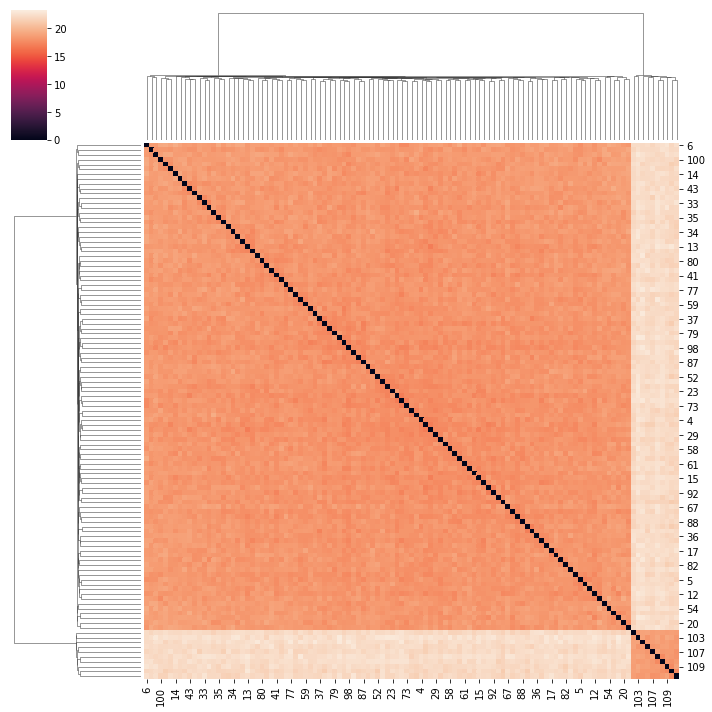

In [99]:
sns.clustermap(squareform(pdist(X)))

In [100]:
import pandas as pd
from sklearn.linear_model import LinearRegression, Lasso

In [101]:
model = Lasso(alpha=0.1)
model.fit(X, y)

Lasso(alpha=0.1)

In [102]:
preds = pd.DataFrame({"y": y, "pred": model.predict(X), "pop": 1})
preds.loc[nsamples:, "pop"] = 2
preds

,y,pred,pop
0,-2.890036,-2.483981,1
1,-7.373928,-5.123978,1
2,0.531391,-0.083482,1
3,-2.648069,-2.437965,1
4,1.311729,0.481124,1
...,...,...,...
106,-0.241730,-0.149222,2
107,-3.778113,-4.339746,2
108,1.488634,0.296920,2
109,0.823477,0.342125,2


In [103]:
preds.groupby("pop").apply(lambda p: ((p["y"] - p["pred"]) ** 2).mean())

pop
1    0.792984
2    0.308206
dtype: float64

In [104]:
effects = pd.DataFrame({"true": true_effects, "pred": model.coef_, "freq1": freqs_pop1, "freq2": freqs_pop2})
effects[effects["true"] != 0].sort_values("true")

,true,pred,freq1,freq2
424,-4.987358,-4.636665,0.782155,0.314272
942,-3.316797,-2.358242,0.294759,0.799501
359,-1.655751,-0.447206,0.902841,0.360887
399,-0.291111,0.000000,0.528208,0.879795
279,-0.212210,-0.000000,0.437959,0.912175
706,0.615461,0.000000,0.589905,0.786503
616,1.582113,0.526349,0.082899,0.794628
476,1.591957,0.008964,0.873217,0.061256
389,2.480210,1.641444,0.239744,0.820666


In [105]:
effects.sort_values("pred").head(10)

,true,pred,freq1,freq2
424,-4.987358,-4.636665,0.782155,0.314272
942,-3.316797,-2.358242,0.294759,0.799501
359,-1.655751,-0.447206,0.902841,0.360887
984,0.000000,-0.131787,0.474286,0.452758
529,0.000000,-0.059976,0.556470,0.096112
847,0.000000,-0.058744,0.647811,0.407043
533,0.000000,-0.045375,0.616533,0.053800
664,0.000000,0.000000,0.734732,0.037101
663,0.000000,-0.000000,0.468895,0.420180
662,0.000000,0.000000,0.285418,0.819648


In [106]:
effects.sort_values("pred").tail(10)

,true,pred,freq1,freq2
337,0.000000,0.000000,0.572401,0.765802
476,1.591957,0.008964,0.873217,0.061256
925,0.000000,0.021720,0.346882,0.865417
744,0.000000,0.033096,0.587489,0.797726
862,0.000000,0.045205,0.328772,0.678966
755,0.000000,0.061040,0.641671,0.571747
85,0.000000,0.074928,0.636585,0.817731
111,0.000000,0.162889,0.515959,0.974238
616,1.582113,0.526349,0.082899,0.794628
389,2.480210,1.641444,0.239744,0.820666


RelieF

In [107]:
dists = squareform(pdist(X))

In [108]:
nneighbors = 5
weights = np.zeros(nloci)

k = 1
n = nsamples + nsamples2
std = np.std(y)
for i in range(n):
    closest_samples = np.argsort(dists[i])

    nhits = 0
    nmiss = 0
    for j in closest_samples:
        if i == j:
            continue
        elif (nhits > k) and (nmiss > k):
            break

        xij = np.abs(X[i,] - X[j,])
        yij = y[i] - y[j]

        if abs(yij) < std:
            # Its a hit
            if nhits > k:
                continue
            weights -= xij / (n * k)
            nhits += 1
        else:
            if nmiss > k:
                continue
            weights += xij / (n * k)
            nmiss += 1

In [109]:
effects = pd.DataFrame({"true": true_effects, "pred": model.coef_, "freq1": freqs_pop1, "freq2": freqs_pop2, "relief": weights})
effects.sort_values("relief", ascending=False)

,true,pred,freq1,freq2,relief
424,-4.987358,-4.636665,0.782155,0.314272,0.963964
942,-3.316797,-2.358242,0.294759,0.799501,0.360360
382,0.000000,-0.000000,0.434281,0.122560,0.351351
681,0.000000,0.000000,0.338203,0.177349,0.333333
130,0.000000,0.000000,0.492619,0.430562,0.279279
...,...,...,...,...,...
126,0.000000,-0.000000,0.348554,0.303019,-0.261261
163,0.000000,0.000000,0.333717,0.824376,-0.261261
695,0.000000,0.000000,0.698863,0.816582,-0.279279
298,0.000000,-0.000000,0.500859,0.073400,-0.279279


In [110]:
effects[effects["true"] != 0]

,true,pred,freq1,freq2,relief
279,-0.212210,-0.000000,0.437959,0.912175,0.027027
359,-1.655751,-0.447206,0.902841,0.360887,0.054054
389,2.480210,1.641444,0.239744,0.820666,0.090090
399,-0.291111,0.000000,0.528208,0.879795,0.036036
424,-4.987358,-4.636665,0.782155,0.314272,0.963964
476,1.591957,0.008964,0.873217,0.061256,-0.135135
616,1.582113,0.526349,0.082899,0.794628,0.045045
706,0.615461,0.000000,0.589905,0.786503,0.198198
942,-3.316797,-2.358242,0.294759,0.799501,0.360360


In [111]:
effects["relief"].describe()

count    1.000000e+03
mean     4.630631e-03
std      1.004398e-01
min     -2.972973e-01
25%     -5.405405e-02
50%      3.469447e-18
75%      6.306306e-02
max      9.639640e-01
Name: relief, dtype: float64

[SKrebate](https://epistasislab.github.io/scikit-rebate/using/) has more algorithms but they are really SLOW.
It's python loops all the way down.

Plenty of other implementations in R.

In [112]:
sim = X.dot(X.T).astype(float)
sim -= sim.min()
sim /= 50 #np.percentile(sim, 25)

<AxesSubplot:>

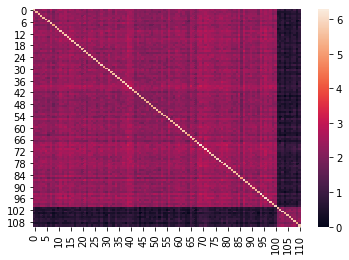

In [113]:
sns.heatmap(sim)

In [114]:
from itertools import combinations

X_pairs = []
y_pairs = []
pair_sim = []

for i, j in combinations(range(X.shape[0]), 2):
    if i == j:
        continue

    if y[i] > y[j]:
        y_pairij = 1
    elif np.abs(y[i] - y[j]) < np.std(y):
        y_pairij = 0.5
    else:
        y_pairij = 0

    X_pairs.append((X[i], X[j]))
    y_pairs.append(y_pairij)
    pair_sim.append(sim[i, j])
    
X_pairs = np.array(X_pairs)
y_pairs = np.array(y_pairs)
pair_sim = np.array(pair_sim)

In [115]:
tf.keras.backend.clear_session()

In [116]:
optimizer = Adam(learning_rate=1)
loss_fn = BinaryCrossentropy(from_logits=True)

model = Sequential([Dense(1, activation="linear", use_bias=False, kernel_regularizer=tf.keras.regularizers.l1(1))])

n_epoch = 100
for _ in range(n_epoch):
    with tf.GradientTape() as tape:
        s1 = model(np.abs(X_pairs[:, 0, :] - X_pairs[:, 1, :]))
        #s2 = model(X_pairs[:, 1, :])
        pred = tfsigmoid(s1)
        loss_value = loss_fn(y_pairs.reshape(-1, 1), pred, sample_weight=pair_sim)

    grads = tape.gradient(loss_value, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

print(loss_value)

tf.Tensor(5.658346, shape=(), dtype=float32)


In [117]:
effects = pd.DataFrame({"true": true_effects, "freq1": freqs_pop1, "freq2": freqs_pop2, "relief": weights, "nn": model.get_weights()[0][:, 0]})
effects.sort_values("nn", ascending=False)

,true,freq1,freq2,relief,nn
869,0.0,0.996953,0.807186,0.009009,7.943168
484,0.0,0.036648,0.687834,-0.072072,4.447771
793,0.0,0.998612,0.596046,0.036036,3.997329
894,0.0,0.097156,0.121705,0.063063,3.377757
561,0.0,0.003345,0.196184,0.000000,3.357172
...,...,...,...,...,...
530,0.0,0.959838,0.461836,0.063063,-3.173112
675,0.0,0.994988,0.836241,0.018018,-3.580165
625,0.0,0.997831,0.423959,0.045045,-3.708804
742,0.0,0.994504,0.051681,0.000000,-4.116137


In [118]:
effects[effects["true"] != 0]

,true,freq1,freq2,relief,nn
279,-0.212210,0.437959,0.912175,0.027027,-0.100957
359,-1.655751,0.902841,0.360887,0.054054,-2.756028
389,2.480210,0.239744,0.820666,0.090090,-0.689894
399,-0.291111,0.528208,0.879795,0.036036,-0.063009
424,-4.987358,0.782155,0.314272,0.963964,-2.341457
476,1.591957,0.873217,0.061256,-0.135135,0.066689
616,1.582113,0.082899,0.794628,0.045045,-2.427979
706,0.615461,0.589905,0.786503,0.198198,-0.165121
942,-3.316797,0.294759,0.799501,0.360360,1.856650


In [119]:
effects["nn"].describe()

count    1000.000000
mean       -0.027586
std         0.865034
min        -4.695507
25%        -0.400552
50%        -0.027578
75%         0.361622
max         7.943168
Name: nn, dtype: float64

<AxesSubplot:xlabel='nn', ylabel='Density'>

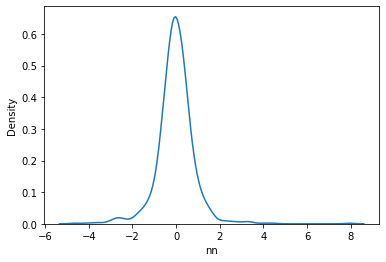

In [120]:
sns.kdeplot(effects["nn"])